# DecodeLabs AI Internship - Project 2 : Data Classification Using AI

## Pipeline:
```
Load → Scale → Split → Train (KNN) → Evaluate → Visualize  
```


### 1. Install dependencies

In [46]:
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score)
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


### 2. Understand Dataset

- **150 samples**
- **3 classes** (Setosa, Versicolor, Virginica)
- **4 features** (sepal/petal length & width).

In [47]:
iris          = load_iris()
X             = iris.data
y             = iris.target
class_names   = iris.target_names
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = [class_names[i] for i in y]

print(f"Shape   : {X.shape}")
print(f"Classes : {class_names}\n")
df.describe().round(2)


Shape   : (150, 4)
Classes : ['setosa' 'versicolor' 'virginica']



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### 3· Feature Scaling & Train-Test Split
- `StandardScaler` normalises each feature to **mean = 0, variance = 1**, so no single feature dominates KNN's distance calculation
- Data is split **80 % training and 20 % testing**, shuffled and stratified to preserve class balance.


In [48]:
# feature scaling
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train-test split
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size = 0.20, random_state = 42, shuffle = True, stratify = y)

print(f"Training samples : {X_train.shape[0]}  (80 %)")
print(f"Testing  samples : {X_test.shape[0]}   (20 %)")
print("\nTest-set class distribution:")
for name, count in zip(class_names, np.bincount(y_test)):
    print(f"  {name:<12} {count} samples")



Training samples : 120  (80 %)
Testing  samples : 30   (20 %)

Test-set class distribution:
  setosa       10 samples
  versicolor   10 samples
  virginica    10 samples


### 4· Elbow Method & Training KNN
We test K = 1 to 20 and pick the value with the **lowest error rate**, then train.

In [49]:
# elbow method
k_range     = range(1, 21)
error_rates = []

for k in k_range:
    knn   = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

optimal_k = list(k_range)[np.argmin(error_rates)]
print(f"🚀 Optimal K = {optimal_k}  (error rate = {min(error_rates):.4f})")

# train final model
model = KNeighborsClassifier(n_neighbors=optimal_k)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f"✅ Model trained")



🚀 Optimal K = 1  (error rate = 0.0333)
✅ Model trained


### 5· Evaluation

In [50]:
acc    = accuracy_score(y_test, predictions)
f1_mac = f1_score(y_test, predictions, average="macro")
cm     = confusion_matrix(y_test, predictions)

print(f"Optimal K : {optimal_k}")
print(f"Accuracy  : {acc*100:.2f} %")
print(f"F1 Score : {f1_mac:.4f}  (macro)")
print(f"Misclassified: {np.sum(predictions != y_test)}/{len(y_test)} samples")
print(f"\nClassification Report:\n")
print(classification_report(y_test, predictions, target_names=class_names))

misclassified = np.sum(predictions != y_test)


Optimal K : 1
Accuracy  : 96.67 %
F1 Score : 0.9666  (macro)
Misclassified: 1/30 samples

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### 6· Sample Prediction

In [51]:
sample        = np.array([[5.1, 3.5, 1.4, 0.2]]) # classic Setosa
sample_scaled = scaler.transform(sample)
pred_class    = model.predict(sample_scaled)[0]
pred_proba    = model.predict_proba(sample_scaled)[0]

print(f"Input     : sepal_l = 5.1, sepal_w = 3.5, petal_l = 1.4, petal_w = 0.2")
print(f"Predicted : {class_names[pred_class].upper()}")
print("\nConfidence:")
for name, prob in zip(class_names, pred_proba):
    print(f"  {name:<12} {prob*100:.1f}%")


Input     : sepal_l = 5.1, sepal_w = 3.5, petal_l = 1.4, petal_w = 0.2
Predicted : SETOSA

Confidence:
  setosa       100.0%
  versicolor   0.0%
  virginica    0.0%


### 7· Visualizations: Elbow Curve + Confusion Matrix + Feature Scaling Comparison

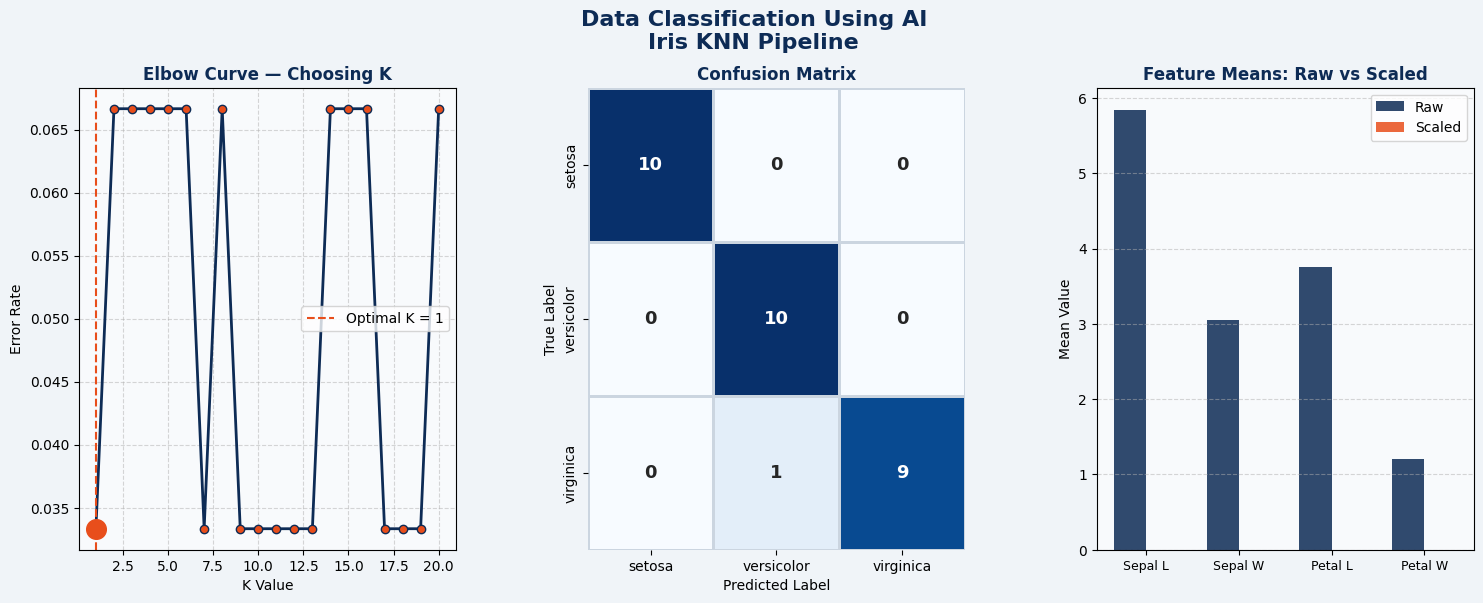


 ✅ Visualisation saved : iris_results.png


In [52]:
fig = plt.figure(figsize=(18, 6), facecolor="#F0F4F8")
fig.suptitle(
    "Data Classification Using AI\nIris KNN Pipeline",
    fontsize=16, fontweight="bold", color="#0D2B55", y=1.01
)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Elbow Curve
ax1 = fig.add_subplot(gs[0])
ax1.plot(list(k_range), error_rates, color="#0D2B55", marker="o",
         markerfacecolor="#E84E1B", linewidth=2, markersize=6)
ax1.axvline(x=optimal_k, color="#E84E1B", linestyle="--", linewidth=1.5,
            label=f"Optimal K = {optimal_k}")
ax1.scatter([optimal_k], [error_rates[optimal_k - 1]], s=200, color="#E84E1B", zorder=5)
ax1.set_title("Elbow Curve — Choosing K", fontweight="bold", color="#0D2B55")
ax1.set_xlabel("K Value"); ax1.set_ylabel("Error Rate")
ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.5)
ax1.set_facecolor("#F8FAFC")

# Confusion Matrix
ax2 = fig.add_subplot(gs[1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor="#CBD5E0", ax=ax2, cbar=False,
            annot_kws={"fontsize": 13, "fontweight": "bold"})
ax2.set_title("Confusion Matrix", fontweight="bold", color="#0D2B55")
ax2.set_xlabel("Predicted Label"); ax2.set_ylabel("True Label")
ax2.set_facecolor("#F8FAFC")

# Feature Scaling Comparison
ax3 = fig.add_subplot(gs[2])
means_raw    = X.mean(axis=0)
means_scaled = np.abs(X_scaled.mean(axis=0))
short_names  = ["Sepal L", "Sepal W", "Petal L", "Petal W"]
x_pos        = np.arange(len(short_names))
width        = 0.35
ax3.bar(x_pos - width/2, means_raw,    width, label="Raw",    color="#0D2B55", alpha=0.85)
ax3.bar(x_pos + width/2, means_scaled, width, label="Scaled", color="#E84E1B", alpha=0.85)
ax3.set_title("Feature Means: Raw vs Scaled", fontweight="bold", color="#0D2B55")
ax3.set_xticks(x_pos); ax3.set_xticklabels(short_names, fontsize=9)
ax3.set_ylabel("Mean Value"); ax3.legend()
ax3.grid(axis="y", linestyle="--", alpha=0.5)
ax3.set_facecolor("#F8FAFC")

plt.tight_layout()
plt.savefig("iris_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n ✅ Visualisation saved : iris_results.png")
